# Upstream Analysis

Analysis of upstream ASes for anycast prefixes using BGP data from bgp.tools.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import numpy as np

plt.style.use('default')
plt.rcParams['axes.labelsize'] = 20
plt.rcParams.update({'font.size': 14})

In [2]:
bgptools = pd.read_json('unique_anycast_bgp_prefixes.json', lines=True)

origins = (
    bgptools
    .explode('OriginASNs')
    .assign(originASN=lambda d: d['OriginASNs'].str['ASN'])
    .groupby('PrefixCIDR')['originASN']
    .unique()
)

upstreams = (
    bgptools
    .explode('Upstreams')
    .assign(upstreamASN=lambda d: d['Upstreams'].str['ASN'])
    .groupby('PrefixCIDR')['upstreamASN']
    .unique()
)

combined = pd.concat([origins, upstreams], axis=1).reset_index()
combined['ip_version'] = combined['PrefixCIDR'].apply(lambda x: 'ipv6' if ':' in x else 'ipv4')
combined.head()

,PrefixCIDR,originASN,upstreamASN,ip_version
0,1.0.0.0/24,[13335],"[12956.0, 174.0, 1299.0, 2914.0, 3356.0, 4637....",ipv4
1,1.1.1.0/24,[13335],"[12956.0, 174.0, 1299.0, 2914.0, 3356.0, 4637....",ipv4
2,1.12.0.0/20,"[132203, 45090]","[1299.0, 3356.0, 6453.0, 7195.0, 7473.0, 58466.0]",ipv4
3,1.12.14.0/23,"[132203, 45090]","[174.0, 1299.0, 3356.0, 3491.0]",ipv4
4,1.12.34.0/23,"[132203, 45090]","[6453.0, 7195.0, 7473.0, 58466.0, 1299.0, 3356.0]",ipv4


## Data Overview

In [3]:
print(f"anycast prefixes: {combined['PrefixCIDR'].nunique():,}")
print(f"anycast ASes (total): {len(set().union(*combined['originASN'])):,}")
print(f"anycast ASes (ipv4):  {len(set().union(*combined[combined['ip_version'] == 'ipv4']['originASN'])):,}")
print(f"anycast ASes (ipv6):  {len(set().union(*combined[combined['ip_version'] == 'ipv6']['originASN'])):,}")
print(f"unique upstream ASes: {combined['upstreamASN'].explode().nunique():,}")

anycast prefixes: 7,442
anycast ASes (total): 1,114
anycast ASes (ipv4):  981
anycast ASes (ipv6):  547
unique upstream ASes: 780


## Top Upstream ASes

In [4]:
exploded_df = combined.explode('upstreamASN')

upstream_stats = (
    exploded_df.groupby(['upstreamASN', 'ip_version'])['PrefixCIDR']
    .nunique()
    .unstack(fill_value=0)
)
upstream_stats = upstream_stats.rename(columns={'ipv4': 'ipv4_prefixes', 'ipv6': 'ipv6_prefixes'})
upstream_stats['unique_prefixes'] = upstream_stats['ipv4_prefixes'] + upstream_stats['ipv6_prefixes']
upstream_stats = upstream_stats.reset_index()
upstream_stats = upstream_stats.sort_values(by='unique_prefixes', ascending=False).reset_index(drop=True)
upstream_stats = upstream_stats[['upstreamASN', 'unique_prefixes', 'ipv4_prefixes', 'ipv6_prefixes']]

upstream_stats['upstreamASN'] = upstream_stats['upstreamASN'].astype(str).apply(
    lambda x: f"AS{x.replace('.0', '')}" if not x.startswith('AS') else x
)

total_ipv4 = combined[combined['ip_version'] == 'ipv4']['PrefixCIDR'].nunique()
total_ipv6 = combined[combined['ip_version'] == 'ipv6']['PrefixCIDR'].nunique()
total_all  = combined['PrefixCIDR'].nunique()

def fmt_stat(count, total):
    pct = (count / total) * 100 if total else 0
    return f"{count:,} ({pct:.1f}\\%)"

upstream_stats['unique_prefixes'] = upstream_stats['unique_prefixes'].apply(lambda x: fmt_stat(x, total_all))
upstream_stats['ipv4_prefixes']   = upstream_stats['ipv4_prefixes'].apply(lambda x: fmt_stat(x, total_ipv4))
upstream_stats['ipv6_prefixes']   = upstream_stats['ipv6_prefixes'].apply(lambda x: fmt_stat(x, total_ipv6))

upstream_stats = upstream_stats.rename(columns={
    'upstreamASN': 'Upstream ASN',
    'unique_prefixes': 'Total Prefixes',
    'ipv4_prefixes': 'IPv4 Prefixes',
    'ipv6_prefixes': 'IPv6 Prefixes'
})

upstream_stats.head(20)

ip_version,Upstream ASN,Total Prefixes,IPv4 Prefixes,IPv6 Prefixes
0,AS1299,"2,977 (40.0\%)","1,751 (37.4\%)","1,226 (44.5\%)"
1,AS174,"2,577 (34.6\%)","1,557 (33.2\%)","1,020 (37.0\%)"
2,AS2914,"2,153 (28.9\%)","1,171 (25.0\%)",982 (35.6\%)
3,AS3356,"2,049 (27.5\%)","1,485 (31.7\%)",564 (20.5\%)
4,AS12956,"1,557 (20.9\%)","1,076 (23.0\%)",481 (17.4\%)
5,AS6453,"1,531 (20.6\%)","1,150 (24.5\%)",381 (13.8\%)
6,AS4637,"1,323 (17.8\%)",624 (13.3\%),699 (25.4\%)
7,AS36236,927 (12.5\%),554 (11.8\%),373 (13.5\%)
8,AS3257,750 (10.1\%),529 (11.3\%),221 (8.0\%)
9,AS4826,708 (9.5\%),402 (8.6\%),306 (11.1\%)


In [5]:
latex_output = upstream_stats.head(20).to_latex(
    index=False,
    column_format='lrrr',
    caption=f"Top Anycast Upstreams by Prefix Count (n={total_all:,})",
    label='tab:anycast_upstreams'
)
print(latex_output)

\begin{table}
\caption{Top Anycast Upstreams by Prefix Count (n=7,442)}
\label{tab:anycast_upstreams}
\begin{tabular}{lrrr}
\toprule
Upstream ASN & Total Prefixes & IPv4 Prefixes & IPv6 Prefixes \\
\midrule
AS1299 & 2,977 (40.0\%) & 1,751 (37.4\%) & 1,226 (44.5\%) \\
AS174 & 2,577 (34.6\%) & 1,557 (33.2\%) & 1,020 (37.0\%) \\
AS2914 & 2,153 (28.9\%) & 1,171 (25.0\%) & 982 (35.6\%) \\
AS3356 & 2,049 (27.5\%) & 1,485 (31.7\%) & 564 (20.5\%) \\
AS12956 & 1,557 (20.9\%) & 1,076 (23.0\%) & 481 (17.4\%) \\
AS6453 & 1,531 (20.6\%) & 1,150 (24.5\%) & 381 (13.8\%) \\
AS4637 & 1,323 (17.8\%) & 624 (13.3\%) & 699 (25.4\%) \\
AS36236 & 927 (12.5\%) & 554 (11.8\%) & 373 (13.5\%) \\
AS3257 & 750 (10.1\%) & 529 (11.3\%) & 221 (8.0\%) \\
AS4826 & 708 (9.5\%) & 402 (8.6\%) & 306 (11.1\%) \\
AS3491 & 555 (7.5\%) & 378 (8.1\%) & 177 (6.4\%) \\
AS20473 & 482 (6.5\%) & 249 (5.3\%) & 233 (8.5\%) \\
AS13335 & 415 (5.6\%) & 368 (7.9\%) & 47 (1.7\%) \\
AS9002 & 372 (5.0\%) & 160 (3.4\%) & 212 (7.7\%) \\
AS6762

## RIR Distribution

In [6]:
rir_summary = bgptools['RIR'].value_counts().to_frame(name='count')
rir_summary['percentage'] = rir_summary['count'] / rir_summary['count'].sum() * 100
rir_summary

,count,percentage
RIR,,
arin,3910,52.539640
ripe,2734,36.737436
apnic,614,8.250470
lacnic,88,1.182478
afrinic,59,0.792798
,37,0.497178


## Upstream Counts per Origin AS

In [7]:
df_pairs = (
    combined
    .explode('originASN')
    .explode('upstreamASN')
    .dropna(subset=['originASN', 'upstreamASN'])
    .drop_duplicates(subset=['originASN', 'upstreamASN'])
)

upstreams_per_origin = (
    df_pairs.groupby('originASN')['upstreamASN']
    .nunique()
    .rename('upstream_count')
)

upstream_popularity = (
    df_pairs.groupby('upstreamASN')['originASN']
    .nunique()
    .sort_values(ascending=False)
    .rename('customer_count')
)

total_unique_origins = df_pairs['originASN'].nunique()

print(f'Total unique origin ASes: {total_unique_origins}')
print(f'\nUpstreams per origin (top 10):')
print(upstreams_per_origin.sort_values(ascending=False).head(10))
print(f'\nMost popular upstreams by customer count (top 10):')
print(upstream_popularity.head(10))

Total unique origin ASes: 1097

Upstreams per origin (top 10):
originASN
54113     40
25152     31
19551     30
139341    23
45102     22
21859     22
203391    22
20144     22
12654     21
199524    19
Name: upstream_count, dtype: int64

Most popular upstreams by customer count (top 10):
upstreamASN
174.0      227
1299.0     224
3356.0     205
20473.0    198
2914.0     160
3257.0     115
6453.0     103
6939.0      98
13335.0     81
6461.0      66
Name: customer_count, dtype: int64


## Single-Upstream Prefixes

In [8]:
single_upstream_df = (
    combined
    .dropna(subset=['upstreamASN'])
    .loc[lambda d: d['upstreamASN'].apply(len) == 1]
    [['PrefixCIDR', 'originASN', 'upstreamASN']]
)
single_upstream_df['UpstreamASN'] = single_upstream_df['upstreamASN'].str[0]

n_v4 = single_upstream_df[~single_upstream_df['PrefixCIDR'].str.contains(':')].shape[0]
n_v6 = single_upstream_df[single_upstream_df['PrefixCIDR'].str.contains(':')].shape[0]
print(f'{len(single_upstream_df)} prefixes with a single upstream ({n_v4} IPv4, {n_v6} IPv6)')

exploded = single_upstream_df.explode('UpstreamASN')
top_sole_providers = (
    exploded.groupby('UpstreamASN')['originASN']
    .apply(lambda s: len(set().union(*s)))
    .sort_values(ascending=False)
    .reset_index()
)
top_sole_providers.columns = ['UpstreamASN', 'unique_ases']

total_unique = len(set().union(*single_upstream_df['originASN']))
top_sole_providers['percentage'] = top_sole_providers['unique_ases'] / total_unique * 100
top_sole_providers.head(10)

2551 prefixes with a single upstream (1745 IPv4, 806 IPv6)


,UpstreamASN,unique_ases,percentage
0,20473.0,84,17.073171
1,13335.0,77,15.650407
2,7342.0,48,9.756098
3,36236.0,36,7.317073
4,60068.0,16,3.252033
5,3356.0,11,2.235772
6,24516.0,11,2.235772
7,174.0,10,2.032520
8,1299.0,9,1.829268
9,15830.0,8,1.626016


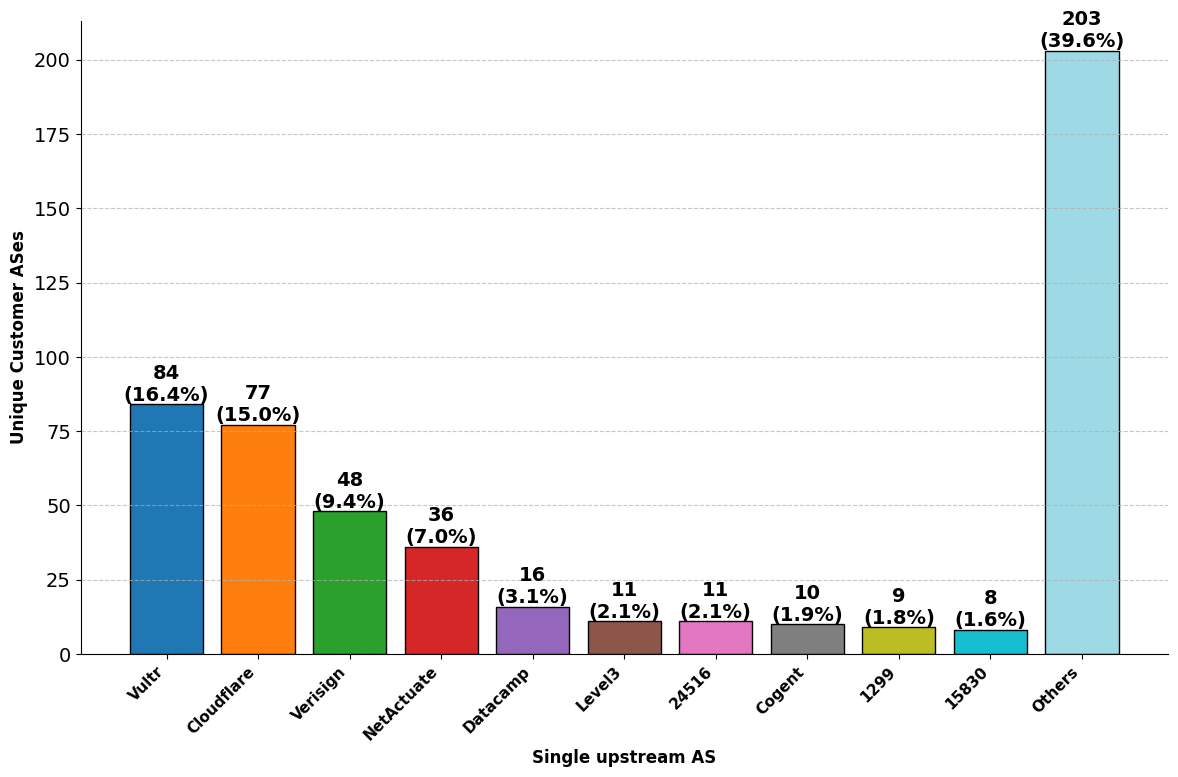

In [9]:
TOP_N = 10

asn_name_map = {
    13335: 'Cloudflare', 174: 'Cogent', 3356: 'Level3',
    7922: 'Comcast', 2914: 'NTT', 36236: 'NetActuate',
    20473: 'Vultr', 20940: 'Akamai', 15169: 'Google',
    16552: 'Tiggee', 7342: 'Verisign', 139341: 'Aceville',
    8075: 'Microsoft', 60068: 'Datacamp'
}

df_clean = top_sole_providers.copy()
df_clean['UpstreamASN'] = pd.to_numeric(df_clean['UpstreamASN'], errors='coerce').fillna(0).astype(int)

df_plot = df_clean.head(TOP_N).copy()
other_count = df_clean.iloc[TOP_N:]['unique_ases'].sum()
other_row = pd.DataFrame({'UpstreamASN': [0], 'unique_ases': [other_count], 'Label': ['Others']})

df_plot['Label'] = df_plot['UpstreamASN'].map(asn_name_map).fillna(df_plot['UpstreamASN'].astype(str))
df_final = pd.concat([df_plot, other_row], ignore_index=True)

plt.figure(figsize=(12, 8))
colors = plt.get_cmap('tab20')(np.linspace(0, 1, len(df_final)))
bars = plt.bar(df_final['Label'], df_final['unique_ases'], color=colors, edgecolor='black')

total = df_final['unique_ases'].sum()
for bar in bars:
    height = bar.get_height()
    pct = f'{(height / total * 100):.1f}%'
    plt.text(bar.get_x() + bar.get_width() / 2., height,
             f'{int(height)}\n({pct})', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.xlabel('Single upstream AS', fontsize=12, fontweight='bold')
plt.ylabel('Unique Customer ASes', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('single_upstreams_ases.pdf', bbox_inches='tight', pad_inches=0.1, facecolor='white')
plt.show()

## Sole vs Shared Customers

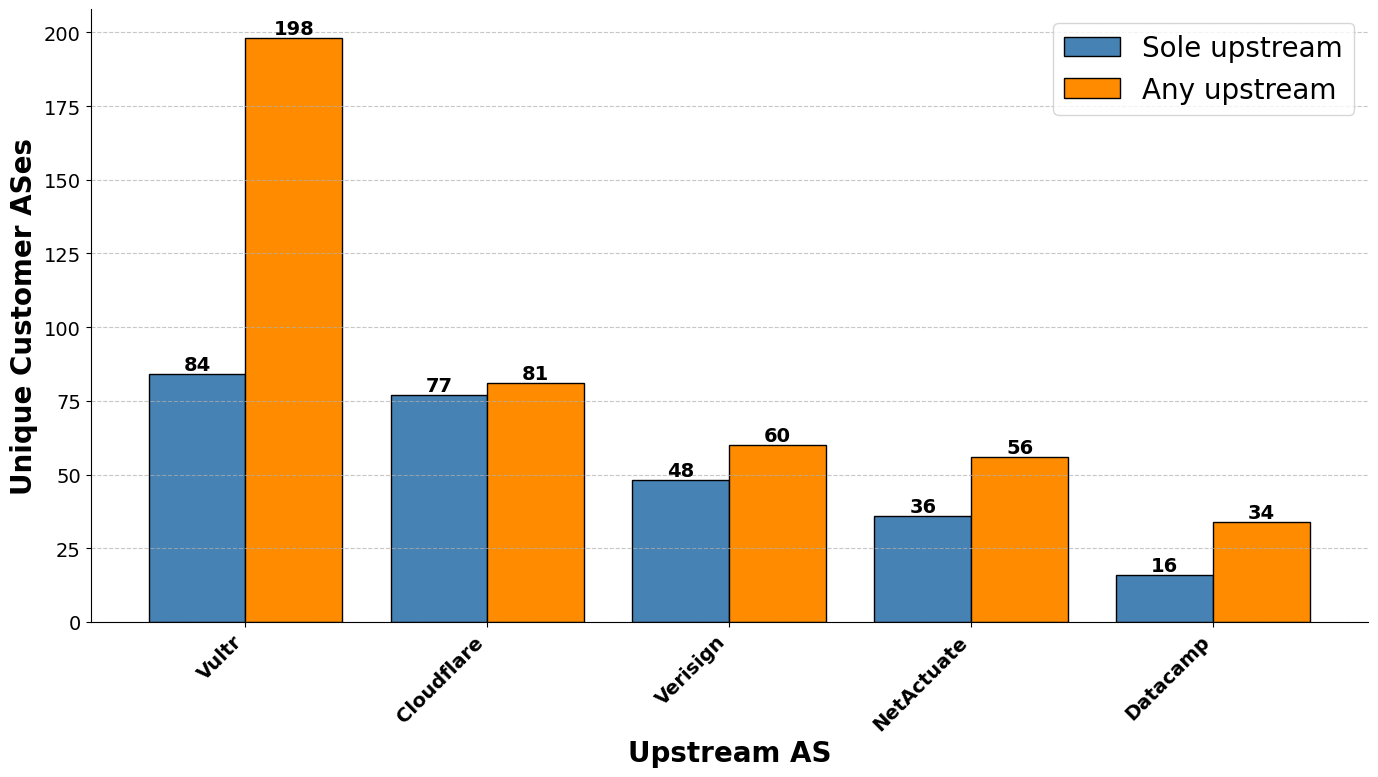

In [10]:
sole_df = combined[combined['upstreamASN'].apply(len) == 1]
sole_counts = (
    sole_df.explode('upstreamASN')
    .groupby('upstreamASN')['originASN']
    .apply(lambda s: len(set().union(*s)))
    .sort_values(ascending=False)
    .reset_index()
)
sole_counts.columns = ['UpstreamASN', 'sole_ases']

all_counts = (
    combined[combined['upstreamASN'].apply(len) >= 1]
    .explode('upstreamASN')
    .groupby('upstreamASN')['originASN']
    .apply(lambda s: len(set().union(*s)))
    .reset_index()
)
all_counts.columns = ['UpstreamASN', 'total_ases']

top5 = (
    sole_counts.head(5)
    .merge(all_counts, on='UpstreamASN', how='left')
    .fillna(0)
    .astype({'total_ases': int})
)
top5['Label'] = top5['UpstreamASN'].map(asn_name_map).fillna(top5['UpstreamASN'].astype(str))

x = np.arange(len(top5))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 8))
bars1 = ax.bar(x - width/2, top5['sole_ases'],  width, label="Sole upstream",  color='steelblue',  edgecolor='black')
bars2 = ax.bar(x + width/2, top5['total_ases'], width, label="Any upstream", color='darkorange', edgecolor='black')

for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                str(int(height)), ha='center', va='bottom', fontweight='bold')

ax.set_xlabel("Upstream AS", fontweight='bold')
ax.set_ylabel('Unique Customer ASes', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top5['Label'], rotation=45, ha='right', fontweight='bold')
ax.legend(fontsize=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('byoip_customer_upstreams_ases.pdf', bbox_inches='tight', pad_inches=0.1, facecolor='white')
plt.show()

## Provider-Adjusted Upstream Counts

BYOIP providers like Cloudflare and Vultr announce customer prefixes through their own AS,
masking the actual number of upstream transit providers. We adjust by weighting each provider
AS with its average upstream count.

In [11]:
byoip_providers = {
    13335: 'Cloudflare', 36236: 'NetActuate', 20473: 'Vultr',
    20940: 'Akamai', 15169: 'Google', 16552: 'Tiggee',
    139341: 'Aceville', 8075: 'Microsoft',
}

single_origin_df = combined[combined['originASN'].apply(len) == 1].copy()
single_origin_df['sole_originASN'] = single_origin_df['originASN'].apply(lambda x: x[0])

target_provider_df = single_origin_df[
    single_origin_df['sole_originASN'].isin(byoip_providers.keys())
]

provider_stats = (
    target_provider_df
    .explode('upstreamASN')
    .dropna(subset=['upstreamASN'])
    .groupby(['PrefixCIDR', 'sole_originASN'])['upstreamASN']
    .nunique()
    .reset_index(name='upstream_count')
)

avg_upstreams_map = provider_stats.groupby('sole_originASN')['upstream_count'].mean().to_dict()
upstream_weights = {asn: avg_upstreams_map.get(asn, 1) for asn in byoip_providers.keys()}

# NetActuate only directly announces a single prefix — use customer-based estimate
upstream_weights[36236] = 2

for asn, name in byoip_providers.items():
    print(f'{name:<12} ({asn}): {upstream_weights[asn]:.2f}')

Cloudflare   (13335): 7.50
NetActuate   (36236): 2.00
Vultr        (20473): 7.10
Akamai       (20940): 5.00
Google       (15169): 4.38
Tiggee       (16552): 3.67
Aceville     (139341): 5.16
Microsoft    (8075): 4.88


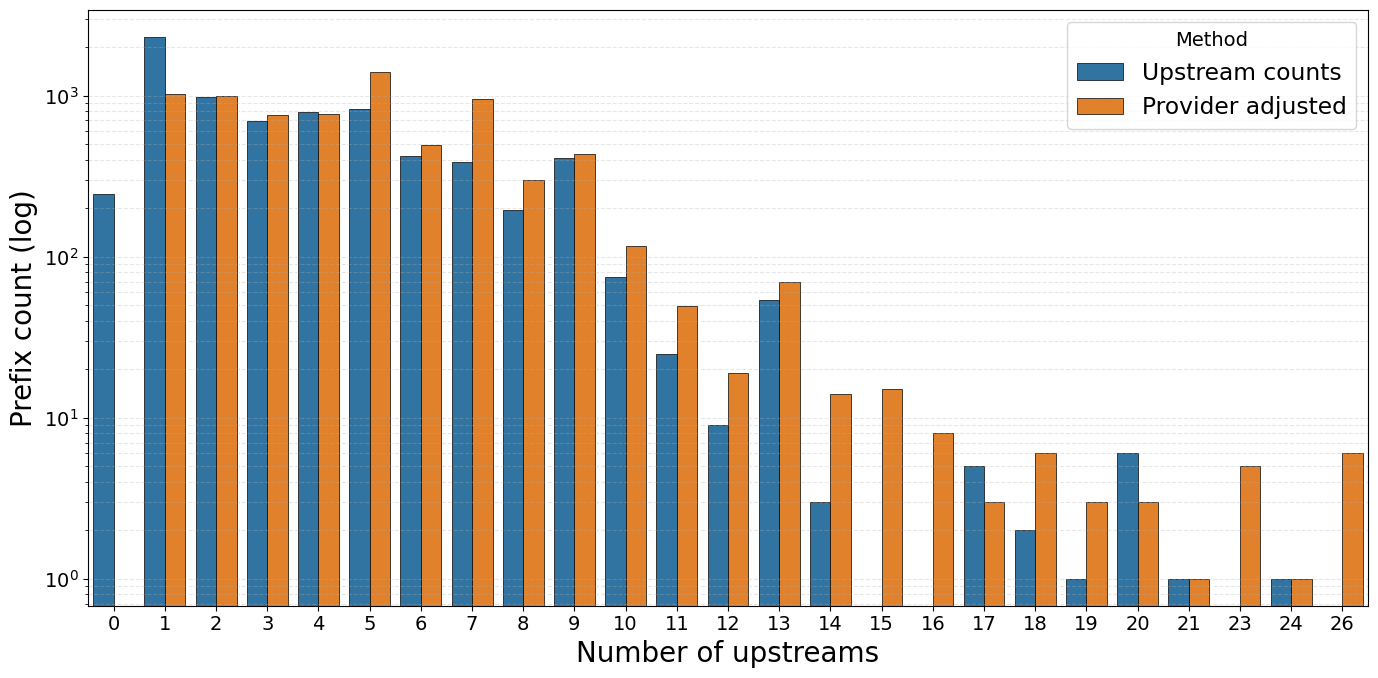

In [12]:
direct_counts = (
    exploded_df
    .groupby('PrefixCIDR')['upstreamASN']
    .nunique()
    .reset_index(name='upstream_count')
)
direct_counts['calculation_method'] = 'Upstream counts'

unique_pairs = exploded_df[['PrefixCIDR', 'upstreamASN']].drop_duplicates()
unique_pairs['weight'] = unique_pairs['upstreamASN'].map(upstream_weights).fillna(1)
adjusted_counts = (
    unique_pairs
    .groupby('PrefixCIDR')['weight']
    .sum()
    .reset_index(name='upstream_count')
)
adjusted_counts['upstream_count'] = adjusted_counts['upstream_count'].round().astype(int)
adjusted_counts['calculation_method'] = 'Provider adjusted'

plot_data = pd.concat([direct_counts, adjusted_counts], ignore_index=True)

freq_df = (
    plot_data
    .groupby(['calculation_method', 'upstream_count'])
    .size()
    .reset_index(name='prefix_count')
    .sort_values('upstream_count')
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=freq_df, x='upstream_count', y='prefix_count',
    hue='calculation_method', palette=['#1f77b4', '#ff7f0e'],
    edgecolor='black', linewidth=0.5
)
plt.yscale('log')
plt.xlabel('Number of upstreams')
plt.ylabel('Prefix count (log)')
plt.grid(True, axis='y', which='both', ls='--', alpha=0.3)
plt.legend(title='Method', fontsize='large')
plt.tight_layout()
plt.savefig('upstream_counts_comparison_bars.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

## MOAS Analysis

In [13]:
moas = combined[combined['originASN'].apply(len) > 1]
origin_counts = combined['originASN'].apply(len)

print(f'MOAS prefixes: {len(moas)}')
print(f'  IPv4: {moas[moas["ip_version"] == "ipv4"].shape[0]}')
print(f'  IPv6: {moas[moas["ip_version"] == "ipv6"].shape[0]}')
print(f'\nOrigin AS count distribution:')
print(origin_counts.value_counts().sort_index())

MOAS prefixes: 315
  IPv4: 204
  IPv6: 111

Origin AS count distribution:
originASN
1     7127
2      205
3       27
4        4
5        5
6        2
7        4
8        7
9       16
10      15
11      14
12      14
14       1
15       1
Name: count, dtype: int64


## BYOIP Provider Summary

In [14]:
byoip_list = {
    'Vultr': 20473, 'Cloudflare': 13335, 'Netactuate': 36236,
    'Google': 15169, 'Akamai': 20940, 'Microsoft': 8075,
    'AWS': 16509, 'Melbicom': 211398,
}

rows = []
for provider, asn in byoip_list.items():
    customers = combined[combined['upstreamASN'].apply(lambda x: asn in x)]
    sole_customers = combined[combined['upstreamASN'].apply(lambda x: set(x) == {asn})]
    rows.append({
        'BYOIP Provider': provider,
        'customer ASes': len(set().union(*customers['originASN'])) if len(customers) > 0 else 0,
        'sole customer ASes': len(set().union(*sole_customers['originASN'])) if len(sole_customers) > 0 else 0,
        'customer prefixes': len(customers),
        'sole customer prefixes': len(sole_customers),
    })

pd.DataFrame(rows)

,BYOIP Provider,customer ASes,sole customer ASes,customer prefixes,sole customer prefixes
0,Vultr,198,84,482,180
1,Cloudflare,81,77,415,402
2,Netactuate,56,36,927,266
3,Google,5,4,192,191
4,Akamai,2,2,219,219
5,Microsoft,1,1,76,76
6,AWS,0,0,0,0
7,Melbicom,0,0,0,0


In [15]:
single_upstream = combined[combined['upstreamASN'].apply(lambda x: len(set(x)) == 1)].copy()
single_upstream['upstream'] = single_upstream['upstreamASN'].apply(lambda x: next(iter(x)))

top10 = (
    single_upstream
    .groupby('upstream')['originASN']
    .apply(lambda s: len(set().union(*s)))
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'originASN': 'unique_origin_ases'})
)

rows = []
for _, row in top10.iterrows():
    asn = row['upstream']
    customers = combined[combined['upstreamASN'].apply(lambda x: asn in x)]
    sole_customers = combined[combined['upstreamASN'].apply(lambda x: set(x) == {asn})]
    rows.append({
        'upstream ASN': asn,
        'customer ASes': len(set().union(*customers['originASN'])) if len(customers) > 0 else 0,
        'sole customer ASes': len(set().union(*sole_customers['originASN'])) if len(sole_customers) > 0 else 0,
        'customer prefixes': len(customers),
        'sole customer prefixes': len(sole_customers),
    })

pd.DataFrame(rows)

,upstream ASN,customer ASes,sole customer ASes,customer prefixes,sole customer prefixes
0,20473.0,198,84,482,180
1,13335.0,81,77,415,402
2,7342.0,60,48,62,57
3,36236.0,56,36,927,266
4,60068.0,34,16,107,46
5,3356.0,205,11,2049,37
6,24516.0,11,11,14,14
7,174.0,227,10,2577,56
8,1299.0,224,9,2977,17
9,15830.0,32,8,58,14
